# Deep Learning Basics: Neural Network Fundamentals

Welcome to **Module 1: Neural Network Fundamentals**. This notebook provides a comprehensive, hands-on deep dive into the mathematical and practical building blocks of neural networks—implemented entirely **from scratch in Python using NumPy and Matplotlib**.

---

## 📋 Table of Contents
1. [Introduction to Neural Networks](#1.-Introduction-to-Neural-Networks)
   - Biological vs. Artificial Neurons
   - The Perceptron Model
   - Implementing a Perceptron from Scratch
   - The XOR Problem & Need for Multi-Layer Networks
2. [Activation Functions](#2.-Activation-Functions)
   - Purpose & Importance of Non-Linearity
   - Sigmoid, Tanh, ReLU, Leaky ReLU, ELU, Softmax
   - Mathematical Formulations & Analytical Derivatives
   - Visualizing Activations & Derivatives
   - Practical Selection Guide & Summary Matrix
3. [Forward Propagation](#3.-Forward-Propagation)
   - Mathematical Formulations
   - Vectorized Matrix Multiplication Approach
   - Complete Multi-Layer Forward Pass Implementation
4. [Loss Functions](#4.-Loss-Functions)
   - Role of Loss Functions in Optimization
   - MSE, Binary Cross-Entropy, Categorical Cross-Entropy, Hinge Loss
   - Numerically Stable NumPy Implementations
   - Visualizing Loss Penalties
5. [Backpropagation & Complete Neural Network](#5.-Backpropagation-&-Complete-Neural-Network)
   - Mathematical Derivation via the Chain Rule
   - Building a Modular `NeuralNetwork` Class from Scratch
   - Solving Non-Linear Problems (XOR & Concentric Circles)
   - Visualizing Loss Curves & Non-Linear Decision Boundaries
6. [Summary & Next Steps](#6.-Summary-&-Next-Steps)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure reproducible random initializations
np.random.seed(42)

# Configure plot aesthetic defaults
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print(f"NumPy Version: {np.__version__}")
print("Environment initialized successfully!")


NumPy Version: 1.26.4
Environment initialized successfully!


## 1. Introduction to Neural Networks

### Biological vs. Artificial Neurons

Artificial Neural Networks (ANNs) were originally inspired by the structure and operation of biological neurons in the human brain.

```
Biological Neuron                    Artificial Neuron
----------------                    -----------------
Dendrites     ===> Input Signals   ===> Inputs (x1, x2, ..., xn)
Synapses      ===> Connection Strength ==> Weights (w1, w2, ..., wn) & Bias (b)
Soma (Cell)   ===> Signal Processing ==> Summation (z = w^T x + b)
Axon          ===> Output Signal   ===> Activation Function f(z) -> Output (y)
```

#### Detailed Architectural Comparison

| Biological Feature | Function in Biology | Artificial Counterpart | Mathematical Representation |
| :--- | :--- | :--- | :--- |
| **Dendrites** | Receive electro-chemical signals from connected neurons | **Input Features** | Vector $\mathbf{x} = [x_1, x_2, \dots, x_n]^T$ |
| **Synapses** | Regulate signal transmission strength across junctions | **Weights & Biases** | Weight vector $\mathbf{w} = [w_1, \dots, w_n]^T$ and scalar bias $b$ |
| **Soma (Cell Body)** | Accumulates incoming signals | **Weighted Summation** | $z = \sum_{i=1}^n w_i x_i + b = \mathbf{w}^T \mathbf{x} + b$ |
| **Axon / Action Potential** | Fires signal if total stimulus exceeds threshold | **Activation Function** | Output $\hat{y} = f(z)$ |

---


### The Perceptron Model

Invented by **Frank Rosenblatt in 1957**, the **Perceptron** is the simplest fundamental building block of artificial neural networks. It is a linear binary classifier that computes a weighted sum of its inputs and applies a step threshold function.

#### Mathematical Formulation

Given an input vector $\mathbf{x} = [x_1, x_2, \dots, x_d]^T \in \mathbb{R}^d$:

1. **Linear Combination (Net Input):**
   $$z = \mathbf{w}^T \mathbf{x} + b = \sum_{i=1}^d w_i x_i + b$$

2. **Heaviside Step Activation Function:**
   $$\hat{y} = f(z) = egin{cases} 1 & 	ext{if } z \ge 0 \ 0 & 	ext{if } z < 0 \end{cases}$$

3. **Perceptron Learning Rule:**
   For each sample $(\mathbf{x}^{(i)}, y^{(i)})$, the weights and bias are updated iteratively:
   $$\Delta \mathbf{w} = \eta \left( y^{(i)} - \hat{y}^{(i)} ight) \mathbf{x}^{(i)}$$
   $$\Delta b = \eta \left( y^{(i)} - \hat{y}^{(i)} ight)$$
   $$\mathbf{w} \leftarrow \mathbf{w} + \Delta \mathbf{w}$$
   $$b \leftarrow b + \Delta b$$

where $\eta \in (0, 1]$ is the learning rate, $y^{(i)} \in \{0, 1\}$ is the ground truth target, and $\hat{y}^{(i)}$ is the predicted class.


In [2]:
class Perceptron:
    """
    Perceptron classifier implemented from scratch using NumPy.
    
    Parameters:
    -----------
    learning_rate : float (default=0.1)
        Learning rate scalar (eta) between 0.0 and 1.0.
    n_epochs : int (default=100)
        Number of passes over the training dataset.
    """
    def __init__(self, learning_rate=0.1, n_epochs=100):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.bias = None
        self.errors_history = []

    def fit(self, X, y):
        """
        Fit training data.
        
        Parameters:
        -----------
        X : np.ndarray, shape = [n_samples, n_features]
            Training feature vectors.
        y : np.ndarray, shape = [n_samples]
            Target binary values (0 or 1).
        """
        n_samples, n_features = X.shape
        
        # Initialize weights to zero or small random values
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.errors_history = []

        for epoch in range(self.n_epochs):
            errors = 0
            for xi, target in zip(X, y):
                # Calculate linear combination z = w^T x + b
                z = np.dot(xi, self.weights) + self.bias
                # Predict using threshold activation
                prediction = 1 if z >= 0 else 0
                
                # Compute error and update rule
                update = self.lr * (target - prediction)
                self.weights += update * xi
                self.bias += update
                
                if update != 0.0:
                    errors += 1
            
            self.errors_history.append(errors)
            if errors == 0:
                print(f"Perceptron converged successfully in epoch {epoch + 1}!")
                break
        return self

    def predict(self, X):
        """Return class label after unit step function."""
        z = np.dot(X, self.weights) + self.bias
        return np.where(z >= 0, 1, 0)

print("Perceptron class defined successfully!")


Perceptron class defined successfully!


--- Training Perceptron on AND Gate ---
Perceptron converged successfully in epoch 4!
AND Gate Predictions: [0 0 0 1] | Ground Truth: [0 0 0 1]

--- Training Perceptron on OR Gate ---
Perceptron converged successfully in epoch 4!
OR Gate Predictions: [0 1 1 1] | Ground Truth: [0 1 1 1]


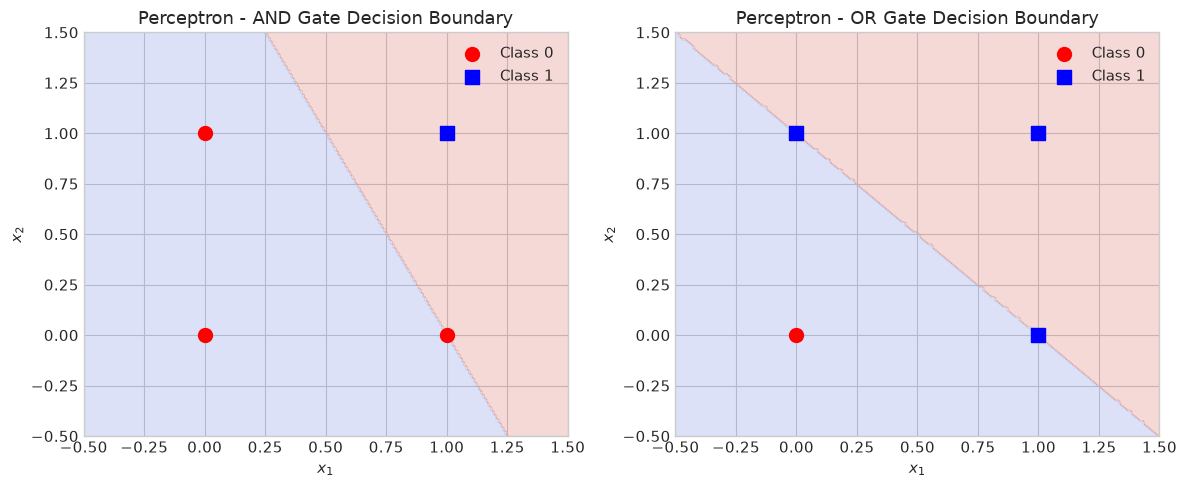

In [3]:
# Define dataset for AND and OR gates
X_gate = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])
y_or = np.array([0, 1, 1, 1])

# Train Perceptron on AND gate
p_and = Perceptron(learning_rate=0.1, n_epochs=20)
print("--- Training Perceptron on AND Gate ---")
p_and.fit(X_gate, y_and)
preds_and = p_and.predict(X_gate)
print("AND Gate Predictions:", preds_and, "| Ground Truth:", y_and)

# Train Perceptron on OR gate
p_or = Perceptron(learning_rate=0.1, n_epochs=20)
print("\n--- Training Perceptron on OR Gate ---")
p_or.fit(X_gate, y_or)
preds_or = p_or.predict(X_gate)
print("OR Gate Predictions:", preds_or, "| Ground Truth:", y_or)

# Plot Decision Boundaries
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

def plot_decision_boundary(ax, model, X, y, title):
    x1_min, x1_max = -0.5, 1.5
    x2_min, x2_max = -0.5, 1.5
    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                           np.linspace(x2_min, x2_max, 200))
    grid = np.c_[xx1.ravel(), xx2.ravel()]
    Z = model.predict(grid).reshape(xx1.shape)
    
    ax.contourf(xx1, xx2, Z, alpha=0.2, cmap='coolwarm')
    ax.scatter(X[y==0, 0], X[y==0, 1], color='red', marker='o', s=100, label='Class 0')
    ax.scatter(X[y==1, 0], X[y==1, 1], color='blue', marker='s', s=100, label='Class 1')
    ax.set_xlim(x1_min, x1_max)
    ax.set_ylim(x2_min, x2_max)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title(title)
    ax.legend()

plot_decision_boundary(axes[0], p_and, X_gate, y_and, 'Perceptron - AND Gate Decision Boundary')
plot_decision_boundary(axes[1], p_or, X_gate, y_or, 'Perceptron - OR Gate Decision Boundary')

plt.tight_layout()
plt.show()


### The XOR Problem & The Need for Multi-Layer Networks

In 1969, **Marvin Minsky and Seymour Papert** published their famous book *Perceptrons*, proving that a single-layer perceptron can **only learn linearly separable patterns**. 

The **XOR (Exclusive OR)** logic function is non-linearly separable:
- $(0,0) 	o 0$
- $(1,1) 	o 0$
- $(0,1) 	o 1$
- $(1,0) 	o 1$

There is no single straight line $w_1 x_1 + w_2 x_2 + b = 0$ that can separate the $0$ outputs from the $1$ outputs.

Below, we observe the Perceptron failing on XOR, demonstrating why we need **Multi-Layer Neural Networks** with non-linear activation functions.


--- Training Perceptron on XOR Gate ---
XOR Predictions: [1 1 0 0] | Ground Truth: [0 1 1 0]
Accuracy: 50.0% (Single Perceptron FAILS to solve XOR)


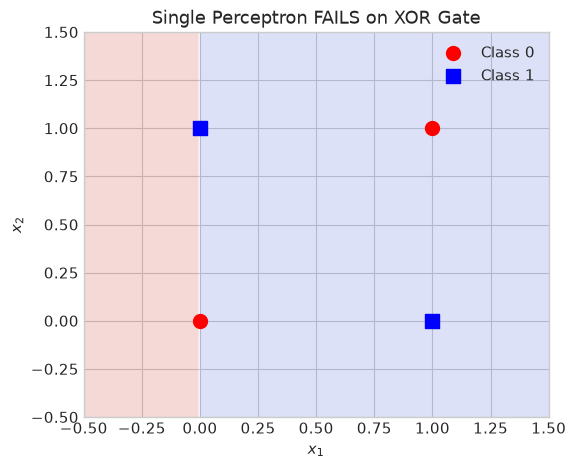

In [4]:
# XOR Dataset
y_xor = np.array([0, 1, 1, 0])

p_xor = Perceptron(learning_rate=0.1, n_epochs=20)
print("--- Training Perceptron on XOR Gate ---")
p_xor.fit(X_gate, y_xor)
preds_xor = p_xor.predict(X_gate)
accuracy = np.mean(preds_xor == y_xor) * 100

print(f"XOR Predictions: {preds_xor} | Ground Truth: {y_xor}")
print(f"Accuracy: {accuracy:.1f}% (Single Perceptron FAILS to solve XOR)")

# Plot XOR Failure
fig, ax = plt.subplots(figsize=(6, 5))
plot_decision_boundary(ax, p_xor, X_gate, y_xor, 'Single Perceptron FAILS on XOR Gate')
plt.show()


## 2. Activation Functions

### Why Do Neural Networks Need Activation Functions?

If a neural network only consisted of linear transformations ($z = W x + b$), cascading multiple hidden layers would result in a single linear function:
$$A^{[2]} = W^{[2]} (W^{[1]} X + b^{[1]}) + b^{[2]} = (W^{[2]} W^{[1]}) X + (W^{[2]} b^{[1]} + b^{[2]}) = W_{composite} X + b_{composite}$$

Without non-linear activation functions, a 100-layer neural network has the exact same representation power as a 1-layer linear model! 

Non-linear activation functions enable neural networks to learn complex non-linear decision boundaries and approximate any continuous function (**Universal Approximation Theorem**).

---


In [5]:
# Implementation of Core Activation Functions and Their Derivatives

def sigmoid(z):
    """Sigmoid activation function: 1 / (1 + e^-z)"""
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_derivative(z):
    """Derivative of Sigmoid: sigma(z) * (1 - sigma(z))"""
    s = sigmoid(z)
    return s * (1.0 - s)

def tanh(z):
    """Hyperbolic Tangent activation function"""
    return np.tanh(z)

def tanh_derivative(z):
    """Derivative of Tanh: 1 - tanh(z)^2"""
    t = tanh(z)
    return 1.0 - t**2

def relu(z):
    """Rectified Linear Unit: max(0, z)"""
    return np.maximum(0, z)

def relu_derivative(z):
    """Derivative of ReLU: 1 if z > 0 else 0"""
    return np.where(z > 0, 1.0, 0.0)

def leaky_relu(z, alpha=0.01):
    """Leaky ReLU: max(alpha * z, z)"""
    return np.where(z > 0, z, alpha * z)

def leaky_relu_derivative(z, alpha=0.01):
    """Derivative of Leaky ReLU: 1 if z > 0 else alpha"""
    return np.where(z > 0, 1.0, alpha)

def elu(z, alpha=1.0):
    """Exponential Linear Unit: z if z > 0 else alpha * (exp(z) - 1)"""
    return np.where(z > 0, z, alpha * (np.exp(np.clip(z, -500, 500)) - 1))

def elu_derivative(z, alpha=1.0):
    """Derivative of ELU: 1 if z > 0 else alpha * exp(z)"""
    return np.where(z > 0, 1.0, alpha * np.exp(np.clip(z, -500, 500)))

def softmax(z):
    """
    Softmax function for multi-class probability distributions.
    Subtracts max(z) for numerical stability (prevents overflow).
    """
    exp_z = np.exp(z - np.max(z, axis=-1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=-1, keepdims=True)

print("Activation functions and derivatives defined successfully!")


Activation functions and derivatives defined successfully!


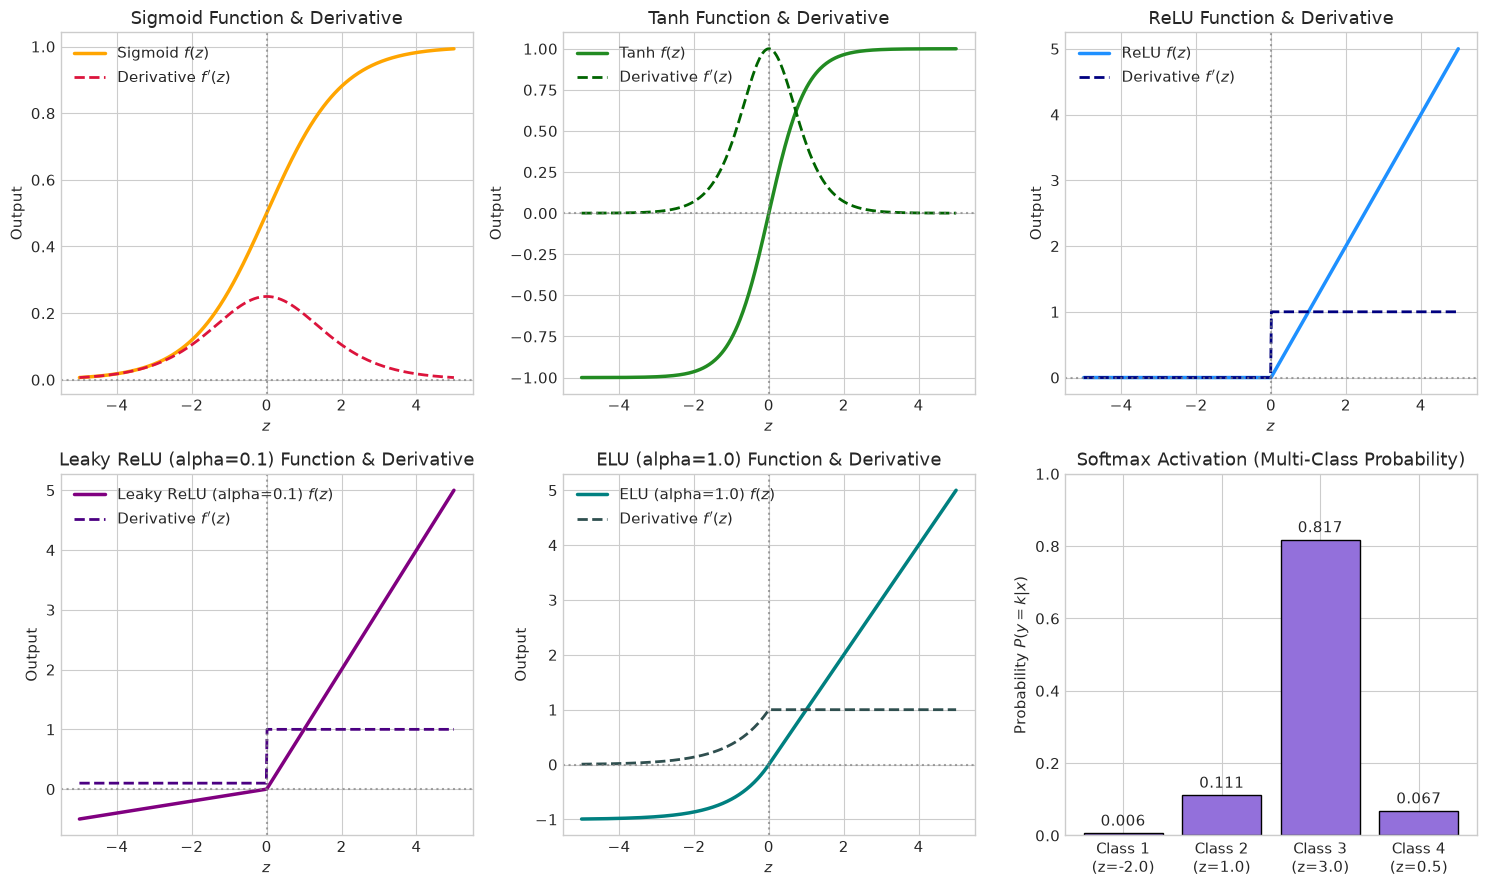

In [6]:
# Visualization of Activation Functions and Derivatives
z_vals = np.linspace(-5, 5, 500)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

activations = [
    ("Sigmoid", sigmoid, sigmoid_derivative, "orange", "crimson"),
    ("Tanh", tanh, tanh_derivative, "forestgreen", "darkgreen"),
    ("ReLU", relu, relu_derivative, "dodgerblue", "navy"),
    ("Leaky ReLU (alpha=0.1)", lambda z: leaky_relu(z, 0.1), lambda z: leaky_relu_derivative(z, 0.1), "purple", "indigo"),
    ("ELU (alpha=1.0)", elu, elu_derivative, "teal", "darkslategrey"),
]

for idx, (name, fn, deriv_fn, color1, color2) in enumerate(activations):
    ax = axes[idx]
    y_act = fn(z_vals)
    y_der = deriv_fn(z_vals)
    
    ax.plot(z_vals, y_act, label=f'{name} $f(z)$', color=color1, linewidth=2.5)
    ax.plot(z_vals, y_der, label=f"Derivative $f'(z)$", color=color2, linewidth=2, linestyle='--')
    ax.axhline(0, color='gray', linestyle=':', alpha=0.7)
    ax.axvline(0, color='gray', linestyle=':', alpha=0.7)
    ax.set_title(f'{name} Function & Derivative')
    ax.set_xlabel('$z$')
    ax.set_ylabel('Output')
    ax.legend(loc='upper left')

# Softmax visualization on 6th subplot
ax_sm = axes[5]
logits = np.array([-2.0, 1.0, 3.0, 0.5])
probs = softmax(logits)
bars = ax_sm.bar([f"Class {i+1}\n(z={logits[i]})" for i in range(len(logits))], probs, color='mediumpurple', edgecolor='black')
ax_sm.set_title('Softmax Activation (Multi-Class Probability)')
ax_sm.set_ylabel('Probability $P(y=k|x)$')
ax_sm.set_ylim(0, 1.0)

for bar in bars:
    height = bar.get_height()
    ax_sm.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()


### When to Use Which Activation Function?

| Activation Function | Formula $f(z)$ | Output Range | Key Pros | Key Cons | Recommended Use Cases |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Sigmoid** | $\frac{1}{1 + e^{-z}}$ | $(0, 1)$ | Smooth, probability interpretation | **Vanishing Gradient problem**, non-zero centered | Output layer for **Binary Classification** |
| **Tanh** | $\frac{e^z - e^{-z}}{e^z + e^{-z}}$ | $(-1, 1)$ | Zero-centered, stronger gradients than Sigmoid | Vanishing gradient for $|z| \gg 0$ | Recurrent networks, older hidden layers |
| **ReLU** | $\max(0, z)$ | $[0, \infty)$ | **Fast computation**, avoids vanishing gradient for $z > 0$, sparse activation | **"Dying ReLU"** problem ($f'(z)=0$ for $z < 0$) | Default choice for **Hidden Layers** in Deep Nets & CNNs |
| **Leaky ReLU** | $\max(\alpha z, z)$ | $(-\infty, \infty)$ | Solves Dying ReLU by keeping small gradient for $z < 0$ | Extra hyperparameter $\alpha$ | Hidden layers when ReLU neurons die |
| **ELU** | $\begin{cases} z & z > 0 \ \alpha(e^z - 1) & z \le 0 \end{cases}$ | $(-\alpha, \infty)$ | Smooth everywhere, zero-centered mean activation | Computationally heavier due to $\exp(z)$ | Deep architectures where ReLU suffers |
| **Softmax** | $\frac{e^{z_i}}{\sum_j e^{z_j}}$ | $(0, 1)$, $\sum = 1$ | Converts arbitrary logits to probability distribution | Sensitive to outliers in logits | Output layer for **Multi-Class Classification** |

---


## 3. Forward Propagation

Forward propagation is the process by which input data passes forward through the layers of a neural network to produce predictions.

### Matrix Multiplication & Layer Calculations

Consider a network with $L$ layers. For any layer $l \in \{1, 2, \dots, L\}$:

1. **Linear Transformation (Weighted Input):**
   $$\mathbf{Z}^{[l]} = \mathbf{A}^{[l-1]} \mathbf{W}^{[l]} + \mathbf{b}^{[l]}$$

2. **Non-Linear Activation:**
   $$\mathbf{A}^{[l]} = g^{[l]}\left(\mathbf{Z}^{[l]}ight)$$

Where:
- $\mathbf{A}^{[0]} = \mathbf{X} \in \mathbb{R}^{N 	imes d_{in}}$ (Input dataset with $N$ samples and $d_{in}$ features)
- $\mathbf{W}^{[l]} \in \mathbb{R}^{n_{l-1} 	imes n_l}$ (Weight matrix connecting layer $l-1$ to layer $l$)
- $\mathbf{b}^{[l]} \in \mathbb{R}^{1 	imes n_l}$ (Bias vector broadcast across $N$ samples)
- $\mathbf{Z}^{[l]} \in \mathbb{R}^{N 	imes n_l}$ (Pre-activation linear matrix)
- $\mathbf{A}^{[l]} \in \mathbb{R}^{N 	imes n_l}$ (Post-activation output matrix)
- $g^{[l]}(\cdot)$ is the activation function at layer $l$

#### Dimension Tracking (Matrix Dimensions)

```
Layer 0 (Input)         Layer 1 (Hidden 1)       Layer 2 (Hidden 2)       Layer 3 (Output)
   X (N x d_in)    -->    W[1] (d_in x h1)  -->    W[2] (h1 x h2)    -->    W[3] (h2 x d_out)
                         b[1] (1 x h1)            b[2] (1 x h2)            b[3] (1 x d_out)
                         A[1] (N x h1)            A[2] (N x h2)            A[3] (N x d_out)
```


In [7]:
class ForwardPassDemo:
    """
    Multi-layer neural network forward propagation demonstrator.
    """
    def __init__(self, architecture):
        """
        architecture: list of ints, e.g., [4, 8, 6, 2]
                      [Input_dim, Hidden1_dim, Hidden2_dim, Output_dim]
        """
        self.architecture = architecture
        self.weights = []
        self.biases = []
        
        # He / Xavier Weight Initialization
        for i in range(len(architecture) - 1):
            fan_in = architecture[i]
            fan_out = architecture[i+1]
            # He initialization scale factor for ReLU
            w = np.random.randn(fan_in, fan_out) * np.sqrt(2.0 / fan_in)
            b = np.zeros((1, fan_out))
            self.weights.append(w)
            self.biases.append(b)

    def forward(self, X):
        """
        Executes vectorized forward pass across all layers.
        Returns final output, cache of Z values, and cache of A values.
        """
        A = X
        A_cache = [A]
        Z_cache = []
        
        print(f"--- Forward Propagation Start ---")
        print(f"Input X shape: {X.shape}")
        
        # Forward pass through hidden layers with ReLU
        for layer_idx in range(len(self.weights) - 1):
            W = self.weights[layer_idx]
            b = self.biases[layer_idx]
            
            Z = np.dot(A, W) + b
            A = relu(Z)
            
            Z_cache.append(Z)
            A_cache.append(A)
            
            print(f"Layer {layer_idx + 1} (Hidden): Z shape = {Z.shape}, A shape = {A.shape}")
            
        # Final output layer with Sigmoid
        W_out = self.weights[-1]
        b_out = self.biases[-1]
        
        Z_out = np.dot(A, W_out) + b_out
        A_out = sigmoid(Z_out)
        
        Z_cache.append(Z_out)
        A_cache.append(A_out)
        
        print(f"Layer {len(self.weights)} (Output): Z shape = {Z_out.shape}, Output A shape = {A_out.shape}")
        return A_out, Z_cache, A_cache

# Create a 3-layer architecture: [4 input features, 8 hidden1, 5 hidden2, 1 output]
demo_net = ForwardPassDemo(architecture=[4, 8, 5, 1])

# Generate a synthetic batch of 5 samples
X_dummy = np.random.randn(5, 4)
output_preds, Z_c, A_c = demo_net.forward(X_dummy)

print("\nFinal Predictions Vector:\n", output_preds)


--- Forward Propagation Start ---
Input X shape: (5, 4)
Layer 1 (Hidden): Z shape = (5, 8), A shape = (5, 8)
Layer 2 (Hidden): Z shape = (5, 5), A shape = (5, 5)
Layer 3 (Output): Z shape = (5, 1), Output A shape = (5, 1)

Final Predictions Vector:
 [[0.50109937]
 [0.5       ]
 [0.38213239]
 [0.2996882 ]
 [0.52586545]]


## 4. Loss Functions

A **Loss Function** (or Cost Function) quantifies how poorly a neural network's predictions match the true targets. It serves as the objective function that the model minimizes during training.

### Core Loss Functions

#### 1. Mean Squared Error (MSE)
Used primarily in **Regression** tasks:
$$\mathcal{L}_{MSE}(\mathbf{y}, \mathbf{\hat{y}}) = rac{1}{2N} \sum_{i=1}^N (y^{(i)} - \hat{y}^{(i)})^2$$

#### 2. Binary Cross-Entropy (BCE / Log Loss)
Used for **Binary Classification** (target $y \in \{0, 1\}$, prediction $\hat{y} \in (0, 1)$):
$$\mathcal{L}_{BCE}(\mathbf{y}, \mathbf{\hat{y}}) = -rac{1}{N} \sum_{i=1}^N \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) ight]$$

#### 3. Categorical Cross-Entropy (CCE)
Used for **Multi-Class Classification** with $K$ classes (targets $y$ are one-hot encoded vectors):
$$\mathcal{L}_{CCE}(\mathbf{Y}, \mathbf{\hat{Y}}) = -rac{1}{N} \sum_{i=1}^N \sum_{k=1}^K y_{i,k} \log(\hat{y}_{i,k})$$

#### 4. Hinge Loss
Used in **Maximum Margin Classifiers** (targets $y \in \{-1, +1\}$):
$$\mathcal{L}_{Hinge}(\mathbf{y}, \mathbf{\hat{y}}) = rac{1}{N} \sum_{i=1}^N \max(0, 1 - y^{(i)} \cdot \hat{y}^{(i)})$$

---


In [8]:
# Implementation of Numerically Stable Loss Functions and Derivatives

def mse_loss(y_true, y_pred):
    """Mean Squared Error Loss"""
    return 0.5 * np.mean((y_true - y_pred) ** 2)

def mse_derivative(y_true, y_pred):
    """Derivative of MSE with respect to y_pred"""
    return (y_pred - y_true) / y_true.size

def binary_cross_entropy(y_true, y_pred, eps=1e-15):
    """
    Binary Cross-Entropy Loss with clipping to prevent log(0) numeric instability.
    """
    y_pred_clipped = np.clip(y_pred, eps, 1.0 - eps)
    loss = -np.mean(y_true * np.log(y_pred_clipped) + (1.0 - y_true) * np.log(1.0 - y_pred_clipped))
    return loss

def binary_cross_entropy_derivative(y_true, y_pred, eps=1e-15):
    """Derivative of BCE with respect to y_pred"""
    y_pred_clipped = np.clip(y_pred, eps, 1.0 - eps)
    return ((y_pred_clipped - y_true) / (y_pred_clipped * (1.0 - y_pred_clipped))) / y_true.size

def categorical_cross_entropy(y_true, y_pred, eps=1e-15):
    """Categorical Cross-Entropy Loss for one-hot encoded targets"""
    y_pred_clipped = np.clip(y_pred, eps, 1.0 - eps)
    return -np.sum(y_true * np.log(y_pred_clipped)) / y_true.shape[0]

def hinge_loss(y_true, y_pred):
    """Hinge Loss for targets in {-1, 1}"""
    return np.mean(np.maximum(0, 1.0 - y_true * y_pred))

# Demonstration with synthetic predictions
y_t = np.array([1, 0, 1, 0])
y_p = np.array([0.9, 0.1, 0.8, 0.3])

print(f"MSE Loss:                   {mse_loss(y_t, y_p):.5f}")
print(f"Binary Cross-Entropy Loss: {binary_cross_entropy(y_t, y_p):.5f}")
print(f"Hinge Loss (y in {-1,1}):   {hinge_loss(2*y_t - 1, 2*y_p - 1):.5f}")


MSE Loss:                   0.01875
Binary Cross-Entropy Loss: 0.19763
Hinge Loss (y in (-1, 1)):   0.35000


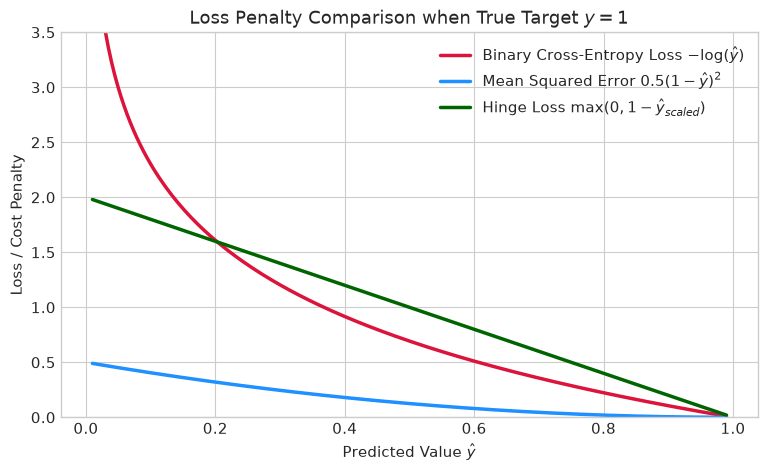

In [9]:
# Visualizing how Loss Penalties scale with Prediction Error for true label y = 1
y_pred_range = np.linspace(0.01, 0.99, 200)
y_true_single = np.ones_like(y_pred_range)

bce_penalties = [-np.log(p) for p in y_pred_range]
mse_penalties = [0.5 * (1 - p)**2 for p in y_pred_range]
hinge_penalties = [max(0, 1 - (1) * (2*p - 1)) for p in y_pred_range]

plt.figure(figsize=(9, 5))
plt.plot(y_pred_range, bce_penalties, label='Binary Cross-Entropy Loss $-\log(\hat{y})$', color='crimson', linewidth=2.5)
plt.plot(y_pred_range, mse_penalties, label='Mean Squared Error $0.5(1 - \hat{y})^2$', color='dodgerblue', linewidth=2.5)
plt.plot(y_pred_range, hinge_penalties, label='Hinge Loss $\max(0, 1 - \hat{y}_{scaled})$', color='darkgreen', linewidth=2.5)

plt.title('Loss Penalty Comparison when True Target $y = 1$')
plt.xlabel('Predicted Value $\hat{y}$')
plt.ylabel('Loss / Cost Penalty')
plt.ylim(0, 3.5)
plt.legend()
plt.show()


## 5. Backpropagation & Complete Neural Network

**Backpropagation** (Backward Propagation of Errors) is the core algorithm used to train neural networks. It calculates the gradient of the loss function with respect to every weight and bias using the **Chain Rule of Calculus**.

### Mathematical Derivation for a 2-Layer Neural Network

Consider a 2-layer network (1 Hidden Layer + 1 Output Layer):
1. $Z^{[1]} = X W^{[1]} + b^{[1]}$
2. $A^{[1]} = 	ext{relu}(Z^{[1]})$
3. $Z^{[2]} = A^{[1]} W^{[2]} + b^{[2]}$
4. $A^{[2]} = \sigma(Z^{[2]}) = \hat{Y}$

Using Binary Cross-Entropy Loss $L(Y, A^{[2]})$, we compute partial derivatives from output layer backwards:

#### Step 1: Output Layer Gradient
$$rac{\partial L}{\partial Z^{[2]}} = A^{[2]} - Y = dZ^{[2]}$$

#### Step 2: Gradients for $W^{[2]}$ and $b^{[2]}$
$$rac{\partial L}{\partial W^{[2]}} = rac{1}{N} (A^{[1]})^T \cdot dZ^{[2]} = dW^{[2]}$$
$$rac{\partial L}{\partial b^{[2]}} = rac{1}{N} \sum_{	ext{rows}} dZ^{[2]} = db^{[2]}$$

#### Step 3: Propagate Gradient to Hidden Layer
$$rac{\partial L}{\partial A^{[1]}} = dZ^{[2]} \cdot (W^{[2]})^T$$
$$rac{\partial L}{\partial Z^{[1]}} = \left( dZ^{[2]} \cdot (W^{[2]})^T ight) \odot 	ext{relu}'(Z^{[1]}) = dZ^{[1]}$$

#### Step 4: Gradients for $W^{[1]}$ and $b^{[1]}$
$$rac{\partial L}{\partial W^{[1]}} = rac{1}{N} X^T \cdot dZ^{[1]} = dW^{[1]}$$
$$rac{\partial L}{\partial b^{[1]}} = rac{1}{N} \sum_{	ext{rows}} dZ^{[1]} = db^{[1]}$$

#### Step 5: Gradient Descent Parameter Update
$$W^{[l]} \leftarrow W^{[l]} - \eta \cdot dW^{[l]}$$
$$b^{[l]} \leftarrow b^{[l]} - \eta \cdot db^{[l]}$$

---


In [10]:
class NeuralNetwork:
    """
    A fully customizable 2-layer Neural Network built from scratch in NumPy.
    Supports Sigmoid, ReLU, and Tanh activation functions for the hidden layer.
    """
    def __init__(self, input_dim, hidden_dim, output_dim, activation='relu', learning_rate=0.1):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.activation_name = activation
        self.lr = learning_rate
        
        # Select activation functions
        if activation == 'relu':
            self.act_fn = relu
            self.act_deriv = relu_derivative
            # He initialization scale factor
            init_scale = np.sqrt(2.0 / input_dim)
        elif activation == 'tanh':
            self.act_fn = tanh
            self.act_deriv = tanh_derivative
            # Xavier initialization scale factor
            init_scale = np.sqrt(1.0 / input_dim)
        elif activation == 'sigmoid':
            self.act_fn = sigmoid
            self.act_deriv = sigmoid_derivative
            init_scale = np.sqrt(1.0 / input_dim)
        else:
            raise ValueError(f"Unsupported activation: {activation}")
            
        # Initialize Layer 1 (Hidden)
        self.W1 = np.random.randn(input_dim, hidden_dim) * init_scale
        self.b1 = np.zeros((1, hidden_dim))
        
        # Initialize Layer 2 (Output)
        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(1.0 / hidden_dim)
        self.b2 = np.zeros((1, output_dim))
        
        self.loss_history = []
        
    def forward(self, X):
        """Forward propagation storing intermediate cache."""
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.act_fn(self.Z1)
        
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = sigmoid(self.Z2) # Output layer sigmoid for binary classification
        return self.A2

    def backward(self, X, Y):
        """Backpropagation calculating analytical gradients via Chain Rule."""
        N = X.shape[0]
        
        # Output layer gradient (dZ2) for BCE + Sigmoid
        dZ2 = self.A2 - Y
        dW2 = np.dot(self.A1.T, dZ2) / N
        db2 = np.sum(dZ2, axis=0, keepdims=True) / N
        
        # Hidden layer gradient (dZ1)
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.act_deriv(self.Z1)
        dW1 = np.dot(X.T, dZ1) / N
        db1 = np.sum(dZ1, axis=0, keepdims=True) / N
        
        # Gradient Descent Parameter Update
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def fit(self, X, Y, epochs=1000, verbose=True):
        """Trains the network using gradient descent."""
        Y = Y.reshape(-1, self.output_dim)
        self.loss_history = []
        
        for epoch in range(epochs):
            # Forward pass
            y_pred = self.forward(X)
            
            # Compute loss
            loss = binary_cross_entropy(Y, y_pred)
            self.loss_history.append(loss)
            
            # Backward pass & parameter update
            self.backward(X, Y)
            
            if verbose and (epoch + 1) % (epochs // 10) == 0:
                acc = np.mean((y_pred >= 0.5) == Y) * 100
                print(f"Epoch {epoch + 1:4d}/{epochs} | BCE Loss: {loss:.5f} | Accuracy: {acc:.2f}%")
                
        return self

    def predict(self, X):
        """Predict binary class labels (0 or 1)."""
        probs = self.forward(X)
        return (probs >= 0.5).astype(int)

print("Modular NeuralNetwork class defined successfully!")


Modular NeuralNetwork class defined successfully!


--- Training Neural Network on XOR Gate ---



Final Performance on XOR Gate:
Input: [0 0] | Prob: 0.0004 | Predicted: 0 | Target: 0
Input: [0 1] | Prob: 0.9968 | Predicted: 1 | Target: 1
Input: [1 0] | Prob: 0.9977 | Predicted: 1 | Target: 1
Input: [1 1] | Prob: 0.0034 | Predicted: 0 | Target: 0


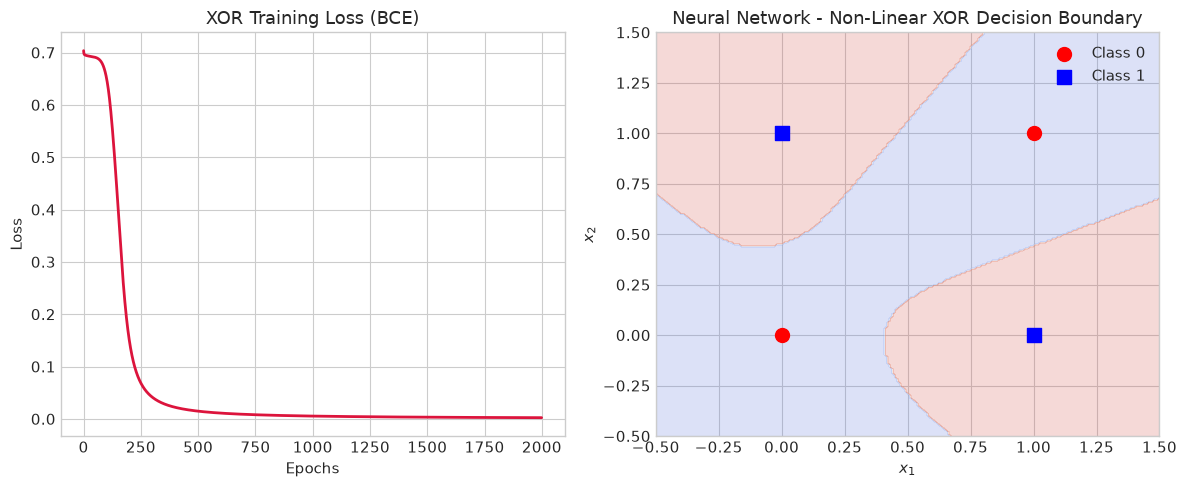

In [11]:
# Solving the Non-Linear XOR Problem with our Neural Network
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0]).reshape(-1, 1)

print("--- Training Neural Network on XOR Gate ---")
nn_xor = NeuralNetwork(input_dim=2, hidden_dim=4, output_dim=1, activation='tanh', learning_rate=0.5)
nn_xor.fit(X_xor, y_xor, epochs=2000, verbose=False)

xor_preds = nn_xor.predict(X_xor)
xor_probs = nn_xor.forward(X_xor)

print("\nFinal Performance on XOR Gate:")
for i in range(len(X_xor)):
    print(f"Input: {X_xor[i]} | Prob: {xor_probs[i][0]:.4f} | Predicted: {xor_preds[i][0]} | Target: {y_xor[i][0]}")

# Plotting Loss Curve & Decision Boundary for XOR
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Loss
axes[0].plot(nn_xor.loss_history, color='crimson', linewidth=2)
axes[0].set_title('XOR Training Loss (BCE)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')

# Plot Decision Boundary
plot_decision_boundary(axes[1], nn_xor, X_xor, y_xor.ravel(), 'Neural Network - Non-Linear XOR Decision Boundary')

plt.tight_layout()
plt.show()


--- Training Neural Network on Concentric Circles Dataset ---
Epoch  250/2500 | BCE Loss: 0.16141 | Accuracy: 100.00%
Epoch  500/2500 | BCE Loss: 0.05255 | Accuracy: 100.00%
Epoch  750/2500 | BCE Loss: 0.02899 | Accuracy: 100.00%
Epoch 1000/2500 | BCE Loss: 0.01963 | Accuracy: 100.00%
Epoch 1250/2500 | BCE Loss: 0.01472 | Accuracy: 100.00%


Epoch 1500/2500 | BCE Loss: 0.01173 | Accuracy: 100.00%
Epoch 1750/2500 | BCE Loss: 0.00973 | Accuracy: 100.00%
Epoch 2000/2500 | BCE Loss: 0.00831 | Accuracy: 100.00%
Epoch 2250/2500 | BCE Loss: 0.00724 | Accuracy: 100.00%
Epoch 2500/2500 | BCE Loss: 0.00641 | Accuracy: 100.00%

Final Training Accuracy on Concentric Circles: 100.00%


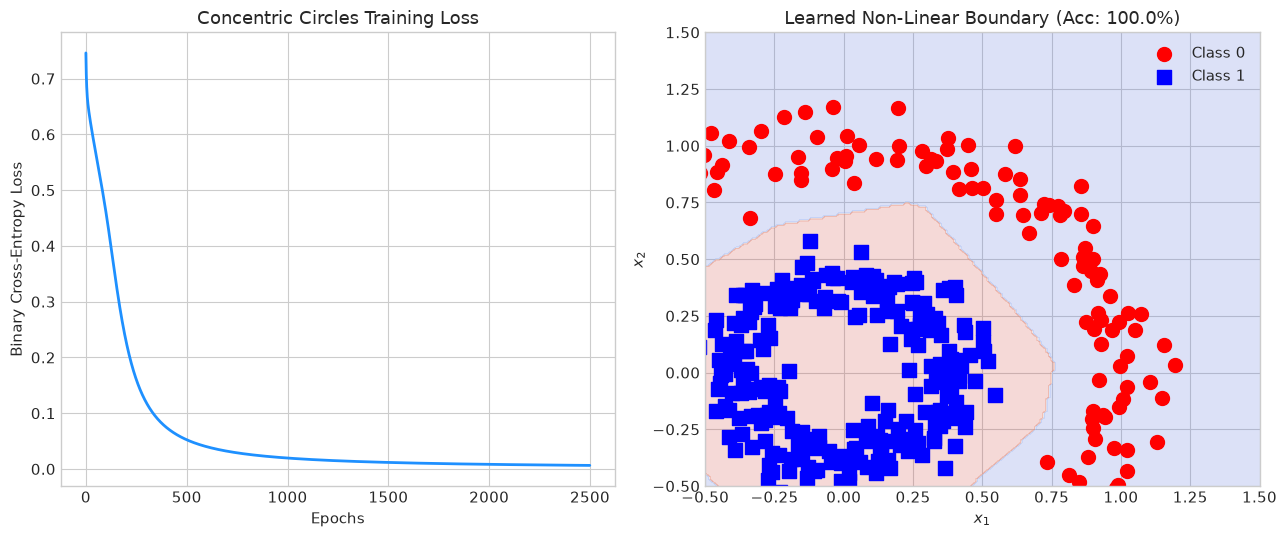

In [12]:
# Synthetic Non-Linear Concentric Circles Dataset
def make_circles(n_samples=400, noise=0.1, factor=0.4):
    """Generates a 2D concentric circles dataset."""
    n_samples_in = n_samples // 2
    n_samples_out = n_samples - n_samples_in
    
    # Outer circle
    linspace_out = np.linspace(0, 2 * np.pi, n_samples_out, endpoint=False)
    outer_x = np.cos(linspace_out)
    outer_y = np.sin(linspace_out)
    
    # Inner circle
    linspace_in = np.linspace(0, 2 * np.pi, n_samples_in, endpoint=False)
    inner_x = np.cos(linspace_in) * factor
    inner_y = np.sin(linspace_in) * factor
    
    X = np.vstack([np.append(outer_x, inner_x), np.append(outer_y, inner_y)]).T
    X += np.random.normal(scale=noise, size=X.shape)
    y = np.hstack([np.zeros(n_samples_out, dtype=int), np.ones(n_samples_in, dtype=int)])
    return X, y

X_circles, y_circles = make_circles(n_samples=500, noise=0.08, factor=0.4)

# Train Neural Network on Concentric Circles
print("--- Training Neural Network on Concentric Circles Dataset ---")
nn_circles = NeuralNetwork(input_dim=2, hidden_dim=12, output_dim=1, activation='relu', learning_rate=0.2)
nn_circles.fit(X_circles, y_circles, epochs=2500, verbose=True)

# Final Accuracy
test_preds = nn_circles.predict(X_circles)
acc = np.mean(test_preds.ravel() == y_circles) * 100
print(f"\nFinal Training Accuracy on Concentric Circles: {acc:.2f}%")

# Plot Loss & Complex Decision Boundary
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Plot Loss Curve
axes[0].plot(nn_circles.loss_history, color='dodgerblue', linewidth=2)
axes[0].set_title('Concentric Circles Training Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Binary Cross-Entropy Loss')

# Plot Decision Boundary
plot_decision_boundary(axes[1], nn_circles, X_circles, y_circles, f'Learned Non-Linear Boundary (Acc: {acc:.1f}%)')

plt.tight_layout()
plt.show()


## 6. Summary & Key Takeaways

In this module, we built and explored the foundational principles of Neural Networks completely from scratch:

1. **Perceptron & Linear Separability**:
   - The basic artificial neuron computes $z = \mathbf{w}^T \mathbf{x} + b$ followed by a step threshold.
   - A single perceptron can only learn linear decision boundaries (solving AND/OR gates) and fails on non-linearly separable data (like XOR).

2. **Activation Functions**:
   - Activation functions introduce non-linearity, enabling deep networks to approximate complex mathematical functions.
   - **ReLU** is the standard default for hidden layers due to fast computation and avoidance of vanishing gradients.
   - **Sigmoid** and **Softmax** are primarily used in output layers to output proper probability distributions.

3. **Forward Propagation**:
   - Input data cascades through layers via vectorized matrix operations: $Z^{[l]} = A^{[l-1]} W^{[l]} + b^{[l]}$ and $A^{[l]} = g(Z^{[l]})$.

4. **Loss Functions**:
   - Measure prediction error to guide parameter updates.
   - **MSE** for regression; **Binary & Categorical Cross-Entropy** for classification.

5. **Backpropagation & Chain Rule**:
   - Backpropagation computes analytical gradients for weights and biases from output back to input using the multivariate chain rule.
   - Gradient descent repeatedly adjusts weights opposite to the gradient to minimize total loss.

---
### 🎓 Next Recommended Step
Proceed to **Module 2: Advanced Optimizers & Regularization**, where we explore SGD with Momentum, RMSprop, Adam, Weight Decay (L2), and Dropout!
